In [1]:
import os
import random
import math
import datetime
import io
import imageio
from base64 import b64encode
from IPython.display import HTML, display
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.tensorboard import SummaryWriter
from minigrid.wrappers import RGBImgObsWrapper
from minigrid.minigrid_env import MiniGridEnv, MissionSpace
from minigrid.core.grid import Grid
from minigrid.core.world_object import Goal, Wall

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


class SimpleEnv(MiniGridEnv):
    # size를 8로 변경하여 내부 6x6 공간 확보
    def __init__(self, size=8, agent_start_pos=(1,1), agent_start_dir=0, max_steps: int | None = None, **kwargs):
        self.agent_start_pos = agent_start_pos
        self.agent_start_dir = agent_start_dir
        mission_space = MissionSpace(mission_func=self._gen_mission)
        super().__init__(mission_space=mission_space, grid_size=size, max_steps=100, **kwargs)

    @staticmethod
    def _gen_mission():
        return "grand mission"

    def _gen_grid(self, width, height):
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)

        # [커스텀 복잡한 미로] 갈림길과 막힌 길(Dead End) 생성

        # 1. 윗부분: 에이전트를 속이는 막힌 길 유도
        self.grid.set(2, 2, Wall())
        self.grid.set(3, 2, Wall())
        self.grid.set(4, 1, Wall())
        self.grid.set(4, 2, Wall())
        self.grid.set(6, 2, Wall())

        # 2. 중간부분: 차단벽 및 두 갈래 길 생성
        self.grid.set(1, 4, Wall())
        # self.grid.set(2, 4, Wall())
        self.grid.set(3, 4, Wall())
        self.grid.set(4, 4, Wall())
        # self.grid.set(5, 4, Wall())
        self.grid.set(6, 3, Wall())

        # 3. 아랫부분: 최종 목적지 앞 장애물
        # self.grid.set(4, 5, Wall())
        # self.grid.set(2, 6, Wall())
        self.grid.set(3, 5, Wall())
        self.grid.set(5, 6, Wall())

        # 목표 지점(Goal) 설정 (6, 6)
        self.grid.set(width - 2, height - 2, Goal())

        # 에이전트 시작 위치 및 방향 설정
        if self.agent_start_pos is not None:
            self.agent_pos = self.agent_start_pos
            self.agent_dir = self.agent_start_dir
        else:
            self.place_agent()

        self.mission = "grand mission"


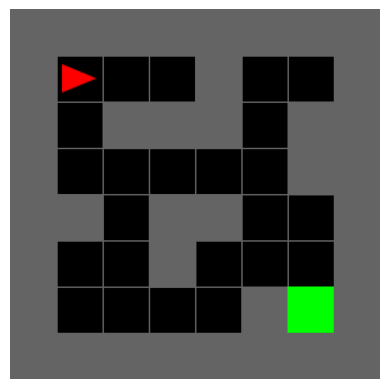

In [2]:
import matplotlib.pyplot as plt

env = SimpleEnv(render_mode="rgb_array")
env.reset()
env.unwrapped.highlight = False

image_data = env.render()
plt.imshow(image_data)
plt.axis("off")
plt.show()

Problem2

In [3]:
# 1. Epsilon-Greedy 정책 함수
def eps_greedy(Q_values, state, epsilon=1.0):
    x, y, d = state[0], state[1], state[2]

    if np.random.rand() < epsilon:
        # 탐험: 0(Left), 1(Right), 2(Forward) 중 무작위 선택
        action = np.random.randint(0, 3)
    else:
        # 활용: 현재 상태에서 가장 Q값이 높은 행동 선택
        action = np.argmax(Q_values[x, y, d])
    return action

# 2. 보상 그래프 출력 함수
def reward_plot(total_reward):
    plt.plot(total_reward, label="Total Reward per Episode")
    plt.xlabel("Episodes")
    plt.ylabel("Total Reward")
    plt.legend()
    plt.show()

# 3. Q-Learning 메인 루프
def run_q_learning(env, Q_values, n_episodes, epsilon, epsilon_decay, gamma, lr):
    total_reward = []

    for i in tqdm(range(n_episodes), desc="Simulating environment", unit="step"):
        obs, info = env.reset(seed=42)

        # 상태(State)를 배열 인덱스에 맞게 변환 (1을 빼서 0부터 시작하도록 맞춤)
        state = np.array([env.agent_pos[0]-1, env.agent_pos[1]-1, obs["direction"]])
        done = False
        reward_sum = 0

        while not done:
            action = eps_greedy(Q_values, state, epsilon)

            # 환경에 행동 가하기
            next_obs, reward, terminated, truncated, info = env.step(action)

            # 다음 상태 정의
            next_state = np.array([env.agent_pos[0]-1, env.agent_pos[1]-1, next_obs["direction"]])

            # 변수 분리
            x, y, d = state[0], state[1], state[2]
            nx, ny, nd = next_state[0], next_state[1], next_state[2]

            # Q값 업데이트 로직 (TD Error 계산)
            best_next_action = np.argmax(Q_values[nx, ny, nd])
            td_target = reward + gamma * Q_values[nx, ny, nd, best_next_action]
            td_error = td_target - Q_values[x, y, d, action]

            Q_values[x, y, d, action] += lr * td_error

            # 상태 및 보상 갱신
            state = next_state
            reward_sum += reward
            done = terminated or truncated

        total_reward.append(reward_sum)

        # 💡 에피소드 종료 시 epsilon 감소 (최소 0.01까지만 감소)
        epsilon = max(epsilon * epsilon_decay, 0.01)

    return Q_values, total_reward

Q-Learning 학습을 시작합니다... (시간이 조금 걸릴 수 있습니다)


Simulating environment: 100%|██████████| 50000/50000 [02:42<00:00, 308.05step/s]


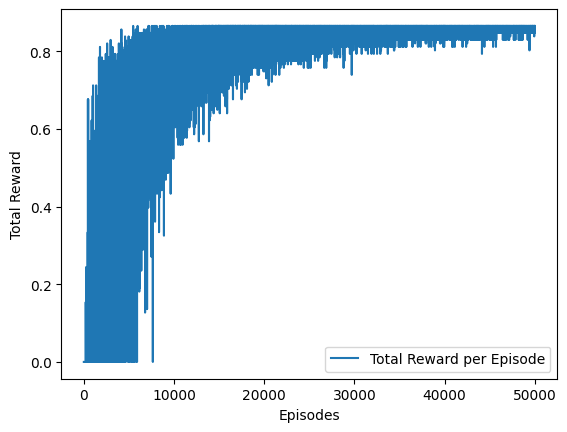

학습 완료!


In [4]:
from tqdm import tqdm
import numpy as np
def main():
    env = SimpleEnv(render_mode="rgb_array")

    # Q-Table 초기화: (가로 6, 세로 6, 방향 4, 행동 3) 차원의 배열
    Q_values_init = np.zeros((env.width-2, env.height-2, 4, 3))

    # 💡 핵심 수정: 에피소드를 5만번으로 늘리고, epsilon이 아주 천천히 깎이도록 수정
    epsilon = 1.0
    epsilon_decay = 0.9999
    gamma = 0.99
    lr = 0.005
    n_episodes = 50000

    print("Q-Learning 학습을 시작합니다... (시간이 조금 걸릴 수 있습니다)")
    Q_values, total_reward = run_q_learning(
        env, Q_values_init, n_episodes, epsilon, epsilon_decay, gamma, lr
    )

    # 학습 결과 그래프 출력
    reward_plot(total_reward)
    print("학습 완료!")

    return Q_values, total_reward

# 실행
learned_Q, q_learning_rewards = main()


In [6]:
import io
import imageio
from base64 import b64encode
from IPython.display import HTML, display
import numpy as np # 혹시 np 에러가 날 경우를 대비해 추가합니다

# 1. 비디오 생성 함수 (교안 37페이지)
def display_video(frames, fps=10, filename=None):
    if isinstance(fps, str):
        filename = fps
        fps = 10
    os.makedirs("video", exist_ok=True)
    if filename:
        save_path = os.path.join("video", filename)
        imageio.mimsave(save_path, frames, format="mp4", fps=fps)
        print(f"Video saved to {save_path}")
    video_buffer = io.BytesIO()
    imageio.mimsave(video_buffer, frames, format="mp4", fps=fps)
    video_buffer.seek(0)
    video_base64 = b64encode(video_buffer.read()).decode()

    video_html = f"""
    <video width="640" height="480" controls autoplay>
    <source src="data:video/mp4;base64,{video_base64}" type="video/mp4">
    </video>
    """
    display(HTML(video_html))

# 2. 학습된 Q-values 테스트 및 프레임 캡처 (교안 38페이지)
def test_and_display(Q_values):
    env = SimpleEnv(render_mode="rgb_array")
    obs, info = env.reset(seed=42)

    # 상태 배열 초기화
    state = np.array([env.agent_pos[0]-1, env.agent_pos[1]-1, obs["direction"]])
    done = False
    frames = []
    frames.append(env.render())

    i = 0
    while not done:
        # 테스트 시에는 무작위 탐험(Epsilon)을 0으로 설정하고 학습된 결과만 100% 활용합니다
        x, y, d = state[0], state[1], state[2]
        action = np.argmax(Q_values[x, y, d])

        # 환경에 행동 가하기
        next_obs, reward, terminated, truncated, info = env.step(action)
        state = np.array([env.agent_pos[0]-1, env.agent_pos[1]-1, next_obs["direction"]])
        done = terminated or truncated

        frames.append(env.render())
        i += 1

        # 에이전트가 길을 찾지 못하고 무한 루프에 빠지는 것을 방지
        if i > 100:
            print("최단 경로 탐색 실패 (무한 루프 방지)")
            break

    env.close()
    print(f"Finished at the {i}-th iteration")

    # 3. 비디오 출력
    display_video(frames)

# 실행: 앞선 블록에서 학습을 마친 learned_Q 변수를 입력으로 넣습니다.
test_and_display(learned_Q)


Finished at the 15-th iteration


# SARSA Implementation
In this section, we implement the SARSA algorithm (On-policy TD Control) and compare it with Q-learning.

In [ ]:
# 4. SARSA 메인 루프
def run_sarsa(env, Q_values, n_episodes, epsilon, epsilon_decay, gamma, lr):
    total_reward = []

    for i in tqdm(range(n_episodes), desc="Simulating SARSA", unit="step"):
        obs, info = env.reset(seed=42)

        # 상태(State)를 배열 인덱스에 맞게 변환
        state = np.array([env.agent_pos[0]-1, env.agent_pos[1]-1, obs["direction"]])
        done = False
        reward_sum = 0

        # On-policy: 현재 상태에서 행동 A 선택
        action = eps_greedy(Q_values, state, epsilon)

        while not done:
            # 행동 A 가하기 -> 다음 상태 S'와 보상 R
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = np.array([env.agent_pos[0]-1, env.agent_pos[1]-1, next_obs["direction"]])

            # On-policy: 다음 상태 S'에서 정책에 따라 다음 행동 A' 선택
            next_action = eps_greedy(Q_values, next_state, epsilon)

            # 변수 분리
            x, y, d = state[0], state[1], state[2]
            nx, ny, nd = next_state[0], next_state[1], next_state[2]

            # Q값 업데이트 로직 (SARSA 업데이트 공식)
            td_target = reward + gamma * Q_values[nx, ny, nd, next_action]
            td_error = td_target - Q_values[x, y, d, action]
            Q_values[x, y, d, action] += lr * td_error

            # 상태 및 행동 갱신
            state = next_state
            action = next_action
            reward_sum += reward
            done = terminated or truncated

        total_reward.append(reward_sum)

        # 에피소드 종료 시 epsilon 감소
        epsilon = max(epsilon * epsilon_decay, 0.01)

    return Q_values, total_reward

def main_sarsa():
    env = SimpleEnv(render_mode="rgb_array")
    Q_values_init = np.zeros((env.width-2, env.height-2, 4, 3))

    epsilon = 1.0
    epsilon_decay = 0.9999
    gamma = 0.99
    lr = 0.005
    n_episodes = 50000

    print("SARSA 학습을 시작합니다... (시간이 조금 걸릴 수 있습니다)")
    Q_values, total_reward = run_sarsa(
        env, Q_values_init, n_episodes, epsilon, epsilon_decay, gamma, lr
    )

    # 학습 결과 그래프 출력
    reward_plot(total_reward)
    print("SARSA 학습 완료!")
    return Q_values, total_reward

learned_Q_sarsa, sarsa_rewards = main_sarsa()

In [ ]:
# SARSA 결과 테스트 및 프레임 캡처
print("--- SARSA 결과 테스트 ---")
test_and_display(learned_Q_sarsa)

# Q-Learning vs SARSA Comparison
Here, we compare the training curves of Q-Learning (Off-policy) and SARSA (On-policy) to understand their convergence behaviors in this maze environment.

In [ ]:
# Q-Learning vs SARSA 학습 곡선 비교 시각화
def compare_plots(q_rewards, sarsa_rewards, window_size=100):
    def moving_average(data, window=window_size):
        return np.convolve(data, np.ones(window)/window, mode='valid')

    plt.figure(figsize=(12, 6))
    
    # Smoothed curves
    plt.plot(moving_average(q_rewards), label="Q-Learning (Smoothed)", color="royalblue", linewidth=2)
    plt.plot(moving_average(sarsa_rewards), label="SARSA (Smoothed)", color="darkorange", linewidth=2)
    
    # Raw rewards (transparent)
    plt.plot(q_rewards, color="royalblue", alpha=0.15)
    plt.plot(sarsa_rewards, color="darkorange", alpha=0.15)
    
    plt.xlabel("Episodes")
    plt.ylabel("Reward")
    plt.title("Q-Learning vs SARSA Reward Comparison")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

compare_plots(q_learning_rewards, sarsa_rewards)

# Problem 3: Deep Q-Learning (DQN)
In this section, we implement a Deep Q-Network (DQN) to solve the same maze environment.
We will compare two different preprocessing approaches:
1. **Grayscale input** (1 channel)
2. **RGB input** (3 channels)

In [7]:
import os
import random
import math
import datetime
import io
import imageio
from base64 import b64encode
from IPython.display import HTML, display
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.tensorboard import SummaryWriter
from minigrid.wrappers import RGBImgObsWrapper
from minigrid.minigrid_env import MiniGridEnv, MissionSpace
from minigrid.core.grid import Grid
from minigrid.core.world_object import Goal, Wall

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

os.makedirs("policy", exist_ok=True)
os.makedirs("video", exist_ok=True)

def get_model_save_path(run_name):
    os.makedirs("policy", exist_ok=True)
    return os.path.join("policy", f"{run_name}_save.pth")

def load_model(model, run_name, filename=None):
    if filename is None:
        filename = f"{run_name}_save.pth"
    if not filename.startswith("policy/") and not filename.startswith("policy\\"):
        path = os.path.join("policy", filename)
    else:
        path = filename
    model.load_state_dict(torch.load(path, map_location=device))
    print(f"Model loaded from {path}")
    return model

def display_video(frames, fps=10, filename=None):
    if isinstance(fps, str):
        filename = fps
        fps = 10
    os.makedirs("video", exist_ok=True)
    if filename:
        save_path = os.path.join("video", filename)
        imageio.mimsave(save_path, frames, format="mp4", fps=fps)
        print(f"Video saved to {save_path}")
    video_buffer = io.BytesIO()
    imageio.mimsave(video_buffer, frames, format="mp4", fps=fps)
    video_buffer.seek(0)
    video_base64 = b64encode(video_buffer.read()).decode()
    video_html = f'<video width="640" height="480" controls autoplay><source src="data:video/mp4;base64,{video_base64}" type="video/mp4"></video>'
    display(HTML(video_html))


Using device: cuda


In [17]:
def pre_state(obs, use_grayscale=True):
    # Extract and normalize image to [0, 1]
    state = obs['image'] / 255.0
    # Convert to PyTorch tensor and permute to (C, H, W)
    state = torch.tensor(state, dtype=torch.float32).permute(2, 0, 1)
    if use_grayscale:
        # Convert 3-channel RGB to 1-channel Grayscale
        to_grayscale = transforms.Grayscale(num_output_channels=1)
        state = to_grayscale(state)
    return state

In [16]:
class ReplayBuffer(object):
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
        
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
        
    def sample(self, batch_size):
        state, action, reward, next_state, done = zip(*random.sample(self.buffer, batch_size))
        return torch.stack(state), action, reward, torch.stack(next_state), done
        
    def __len__(self):
        return len(self.buffer)

In [15]:
class Model(nn.Module):
    def __init__(self, input_shape, num_actions):
        super(Model, self).__init__()
        in_channels = input_shape[0] # 1 for grayscale, 3 for RGB
        
        self.conv1 = nn.Conv2d(in_channels, 16, kernel_size=5, stride=2, padding=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=1)
        
        # input 64x64 -> conv1 output is 32x32 -> conv2 output is 16x16 -> conv3 output is 8x8
        # flattened size: 32 * 8 * 8 = 2048
        self.fc1 = nn.Linear(32 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, num_actions)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.reshape(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [14]:
def eps_greedy(model, state, epsilon):
    if random.random() < epsilon:
        action = random.randint(0, 2) # Left, Right, Forward
    else:
        state_tensor = state.unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = model(state_tensor)
            action = q_values.argmax(dim=1).item()
    return action

def update_target(current_model, target_model):
    target_model.load_state_dict(current_model.state_dict())

def compute_td_error(batch_size, replay_buffer, model, target_model, gamma, optimizer):
    if batch_size > len(replay_buffer):
        return None
        
    state, action, reward, next_state, done = replay_buffer.sample(batch_size)
    
    state = state.to(device)
    next_state = next_state.to(device)
    
    action = torch.tensor(action, dtype=torch.long).unsqueeze(1).to(device)
    reward = torch.tensor(reward, dtype=torch.float32).unsqueeze(1).to(device)
    mask = torch.tensor(1 - np.float32(done), dtype=torch.float32).unsqueeze(1).to(device)
    
    q_values = model(state)
    q_value = q_values.gather(1, action)
    
    with torch.no_grad():
        next_q_values = target_model(next_state)
        next_q_value = next_q_values.max(dim=1, keepdim=True)[0]
        td_target = reward + gamma * next_q_value * mask
        
    loss = F.mse_loss(q_value, td_target)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [12]:
def run_dqn(use_grayscale=True, n_episodes=3000, lr=1e-4, batch_size=64, Target_Update=10, epsilon_decay=0.998, run_name="DQN"):
    env = SimpleEnv(render_mode="rgb_array")
    env = RGBImgObsWrapper(env)
    
    input_channels = 1 if use_grayscale else 3
    model = Model((input_channels, 64, 64), 3).to(device)
    target_model = Model((input_channels, 64, 64), 3).to(device)
    update_target(model, target_model)
    target_model.eval()
    
    optimizer = optim.RMSprop(model.parameters(), lr=lr)
    replay_buffer = ReplayBuffer(10000)
    
    writer = SummaryWriter(log_dir=f"runs/{run_name}")
    
    epsilon = 1.0
    epsilon_min = 0.01
    gamma = 0.99
    
    total_rewards = []
    goal = [env.width - 3, env.height - 3] # 0-indexed goal: [5, 5]
    
    progress_bar = tqdm(range(n_episodes), desc=f"Training {run_name}", unit="episode")
    for episode in progress_bar:
        obs, info = env.reset(seed=42)
        state = pre_state(obs, use_grayscale=use_grayscale)
        
        # Initial distance (0-indexed)
        distance = math.sqrt((goal[0] - (env.agent_pos[0]-1))**2 + (goal[1] - (env.agent_pos[1]-1))**2)
        done = False
        episode_reward = 0
        episode_shaped_reward = 0
        losses = []
        
        while not done:
            action = eps_greedy(model, state, epsilon)
            
            # Step in environment
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = pre_state(next_obs, use_grayscale=use_grayscale)
            
            # 0-indexed next distance
            next_distance = math.sqrt((goal[0] - (env.agent_pos[0]-1))**2 + (goal[1] - (env.agent_pos[1]-1))**2)
            
            # Additional reward (reward shaping with penalty)
            shaped_reward = reward + (distance - next_distance) - 0.01
            
            # Store in replay buffer
            replay_buffer.push(state, action, shaped_reward, next_state, terminated)
            
            # Train
            loss = compute_td_error(batch_size, replay_buffer, model, target_model, gamma, optimizer)
            if loss is not None:
                losses.append(loss)
                
            state = next_state
            distance = next_distance
            episode_reward += reward
            episode_shaped_reward += shaped_reward
            done = terminated or truncated
            
        # Decay epsilon
        epsilon = max(epsilon * epsilon_decay, epsilon_min)
        
        # Update target network
        if episode % Target_Update == 0:
            update_target(model, target_model)
            
        # Logging
        mean_loss = np.mean(losses) if losses else 0
        total_rewards.append(episode_reward)
        
        writer.add_scalar("Reward/True", episode_reward, episode)
        writer.add_scalar("Reward/Shaped", episode_shaped_reward, episode)
        writer.add_scalar("Loss", mean_loss, episode)
        writer.add_scalar("Epsilon", epsilon, episode)
        
        progress_bar.set_postfix({
            "True Reward": f"{episode_reward:.2f}",
            "Loss": f"{mean_loss:.4f}",
            "Epsilon": f"{epsilon:.3f}"
        })
        
    writer.close()
    
    # Save the trained model
    save_path = get_model_save_path(run_name)
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")
    return model, total_rewards


## 1. Train DQN with Grayscale Inputs

In [18]:
# Train grayscale model
model_grayscale, rewards_grayscale = run_dqn(
    use_grayscale=True,
    n_episodes=3000,
    lr=1e-4,
    batch_size=64,
    Target_Update=10,
    epsilon_decay=0.998,
    run_name="DQN_Grayscale"
)

/home/ash/projects/51_optimization_project3/.venv/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.width to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.width` for environment variables or `env.get_wrapper_attr('width')` that will search the reminding wrappers.
  logger.warn(
/home/ash/projects/51_optimization_project3/.venv/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.height to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.height` for environment variables or `env.get_wrapper_attr('height')` that will search the reminding wrappers.
  logger.warn(


Training DQN_Grayscale:   0%|          | 0/3000 [00:00<?, ?episode/s]/home/ash/projects/51_optimization_project3/.venv/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.agent_pos to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.agent_pos` for environment variables or `env.get_wrapper_attr('agent_pos')` that will search the reminding wrappers.
  logger.warn(
Training DQN_Grayscale: 100%|██████████| 3000/3000 [05:24<00:00,  9.24episode/s, True Reward=0.86, Loss=0.0007, Epsilon=0.010]


Model saved to DQN_Grayscale_save.pth


## 2. Train DQN with RGB (Color) Inputs

In [19]:
# Train RGB model
model_rgb, rewards_rgb = run_dqn(
    use_grayscale=False,
    n_episodes=3000,
    lr=1e-4,
    batch_size=64,
    Target_Update=10,
    epsilon_decay=0.998,
    run_name="DQN_RGB"
)

Training DQN_RGB: 100%|██████████| 3000/3000 [06:37<00:00,  7.54episode/s, True Reward=0.85, Loss=0.0014, Epsilon=0.010]


Model saved to DQN_RGB_save.pth


## 3. Compare and Test the Models

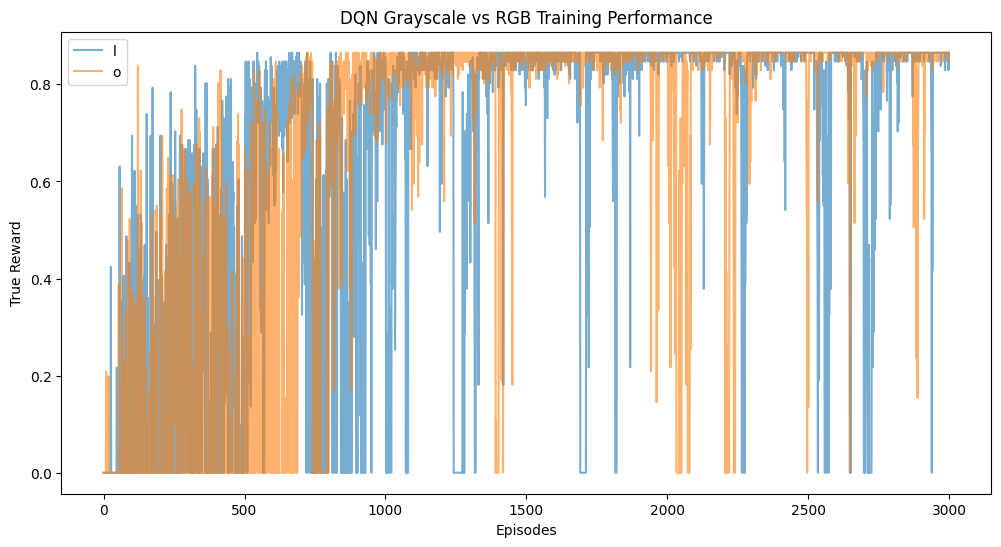

In [ ]:
# Plot Comparison of True Rewards

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(rewards_grayscale, label="DQN Grayscale", alpha=0.6)
plt.plot(rewards_rgb, label="DQN RGB", alpha=0.6)
plt.xlabel("Episodes")
plt.ylabel("True Reward")
plt.title("DQN Grayscale vs RGB Training Performance")
plt.legend(loc='lower right')
plt.show()

In [21]:
# Test function for DQN models
def test_dqn(model, use_grayscale=True):
    env = SimpleEnv(render_mode="rgb_array")
    env = RGBImgObsWrapper(env)
    obs, info = env.reset(seed=42)
    state = pre_state(obs, use_grayscale=use_grayscale)
    done = False
    frames = [env.render()]
    
    steps = 0
    while not done and steps < 100:
        state_tensor = state.unsqueeze(0).to(device)
        with torch.no_grad():
            action = model(state_tensor).argmax(dim=1).item()
        next_obs, reward, terminated, truncated, info = env.step(action)
        state = pre_state(next_obs, use_grayscale=use_grayscale)
        done = terminated or truncated
        frames.append(env.render())
        steps += 1
        
    env.close()
    print(f"Finished in {steps} steps")
    return frames

print("Testing Grayscale Model...")
grayscale_frames = test_dqn(model_grayscale, use_grayscale=True)
display_video(grayscale_frames, filename="dqn_grayscale_play.mp4")

print("Testing RGB Model...")
rgb_frames = test_dqn(model_rgb, use_grayscale=False)
display_video(rgb_frames, filename="dqn_rgb_play.mp4")

Testing Grayscale Model...
Finished in 15 steps


Testing RGB Model...
Finished in 100 steps


## DQN with Early Stopping

Introduce an early stopping condition that terminates training when the moving average of the last 100 episodes' True Reward reaches a threshold (0.84 or above) and Epsilon is 0.05 or lower. This reduces training time and prevents overfitting.


In [ ]:
def run_dqn_early_stopping(use_grayscale=True, n_episodes=3000, lr=1e-4, batch_size=64, Target_Update=10, epsilon_decay=0.998, run_name="DQN_ES", target_avg_reward=0.84):
    env = SimpleEnv()
    env = RGBImgObsWrapper(env)
    
    input_channels = 1 if use_grayscale else 3
    model = Model((input_channels, 64, 64), 3).to(device)
    target_model = Model((input_channels, 64, 64), 3).to(device)
    update_target(model, target_model)
    target_model.eval()
    
    optimizer = optim.RMSprop(model.parameters(), lr=lr)
    replay_buffer = ReplayBuffer(10000)
    
    writer = SummaryWriter(log_dir=f"runs/{run_name}")
    
    epsilon = 1.0
    epsilon_min = 0.01
    gamma = 0.99
    
    total_rewards = []
    recent_rewards = deque(maxlen=100)
    goal = [env.width - 3, env.height - 3]
    
    progress_bar = tqdm(range(n_episodes), desc=f"Training {run_name}", unit="episode")
    for episode in progress_bar:
        obs, info = env.reset(seed=42)
        state = pre_state(obs, use_grayscale=use_grayscale)
        
        distance = math.sqrt((goal[0] - (env.agent_pos[0]-1))**2 + (goal[1] - (env.agent_pos[1]-1))**2)
        done = False
        episode_reward = 0
        episode_shaped_reward = 0
        losses = []
        
        while not done:
            action = eps_greedy(model, state, epsilon)
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = pre_state(next_obs, use_grayscale=use_grayscale)
            
            next_distance = math.sqrt((goal[0] - (env.agent_pos[0]-1))**2 + (goal[1] - (env.agent_pos[1]-1))**2)
            
            # Additional reward
            shaped_reward = reward + (distance - next_distance) - 0.01
            
            replay_buffer.push(state, action, shaped_reward, next_state, terminated)
            
            loss = compute_td_error(batch_size, replay_buffer, model, target_model, gamma, optimizer)
            if loss is not None:
                losses.append(loss)
                
            state = next_state
            distance = next_distance
            episode_reward += reward
            episode_shaped_reward += shaped_reward
            done = terminated or truncated
            
        epsilon = max(epsilon * epsilon_decay, epsilon_min)
        
        if episode % Target_Update == 0:
            update_target(model, target_model)
            
        mean_loss = np.mean(losses) if losses else 0
        total_rewards.append(episode_reward)
        recent_rewards.append(episode_reward)
        
        writer.add_scalar("Reward/True", episode_reward, episode)
        writer.add_scalar("Reward/Shaped", episode_shaped_reward, episode)
        writer.add_scalar("Loss", mean_loss, episode)
        writer.add_scalar("Epsilon", epsilon, episode)
        
        # Early Stopping Condition
        if len(recent_rewards) == 100:
            avg_reward = np.mean(recent_rewards)
            if avg_reward >= target_avg_reward and epsilon <= 0.05:
                print(f"\n[Early Stopping] Target average reward {target_avg_reward} achieved: {avg_reward:.4f} over last 100 episodes. Epsilon: {epsilon:.3f}. Stopping training at episode {episode+1}.")
                break
                
        if (episode + 1) % 100 == 0:
            print(f"[{run_name}] Episode {episode+1}/{n_episodes} - True Reward: {episode_reward:.2f}, Loss: {mean_loss:.4f}, Epsilon: {epsilon:.3f}")
            
    writer.close()
    save_path = get_model_save_path(run_name)
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")
    return model, total_rewards


### Train Early Stopping Models

Train the Grayscale and RGB models with the early stopping condition implemented.


In [ ]:
print("--- Training Grayscale with Early Stopping ---")
model_grayscale_es, rewards_grayscale_es = run_dqn_early_stopping(
    use_grayscale=True,
    n_episodes=3000,
    run_name="DQN_Grayscale_ES"
)

print("\n--- Training RGB with Early Stopping ---")
model_rgb_es, rewards_rgb_es = run_dqn_early_stopping(
    use_grayscale=False,
    n_episodes=3000,
    run_name="DQN_RGB_ES"
)

### Grayscale DQN Hyperparameter Tuning with Early Stopping

To analyze the impact of different hyperparameters on training performance and convergence speed, we train two additional Grayscale DQN variants with early stopping:
1. **Larger Batch Size**: `batch_size = 256` (instead of 64)
2. **Faster Epsilon Decay**: `epsilon_decay = 0.9` (instead of 0.998)

In [62]:
print("--- Training Grayscale ES (Batch Size = 256) ---")
model_grayscale_es_bs256, rewards_grayscale_es_bs256 = run_dqn_early_stopping(
    use_grayscale=True,
    n_episodes=3000,
    batch_size=256,
    run_name="DQN_Grayscale_ES_BS256"
)

print("\n--- Training Grayscale ES (Epsilon Decay = 0.9) ---")
model_grayscale_es_ed09, rewards_grayscale_es_ed09 = run_dqn_early_stopping(
    use_grayscale=True,
    n_episodes=3000,
    epsilon_decay=0.9,
    run_name="DQN_Grayscale_ES_ED09"
)

--- Training Grayscale ES (Batch Size = 256) ---


Training DQN_Grayscale_ES_BS256:   3%|▎         | 100/3000 [00:40<20:04,  2.41episode/s]

[DQN_Grayscale_ES_BS256] Episode 100/3000 - True Reward: 0.00, Loss: 0.0058, Epsilon: 0.819


Training DQN_Grayscale_ES_BS256:   7%|▋         | 200/3000 [01:18<17:09,  2.72episode/s]

[DQN_Grayscale_ES_BS256] Episode 200/3000 - True Reward: 0.00, Loss: 0.0065, Epsilon: 0.670


...

[DQN_Grayscale_ES_ED09] Episode 1500/3000 - True Reward: 0.00, Loss: 0.0010, Epsilon: 0.010


Training DQN_Grayscale_ES_ED09:  53%|█████▎    | 1602/3000 [07:28<01:33, 14.98episode/s]

[DQN_Grayscale_ES_ED09] Episode 1600/3000 - True Reward: 0.86, Loss: 0.0001, Epsilon: 0.010


Training DQN_Grayscale_ES_ED09:  56%|█████▌    | 1670/3000 [07:32<06:00,  3.69episode/s]


[Early Stopping] Target average reward 0.84 achieved: 0.8460 over last 100 episodes. Epsilon: 0.010. Stopping training at episode 1671.
Model saved to policy/DQN_Grayscale_ES_ED09_save.pth


### Compare Hyperparameter Tuning Results

We plot and compare the training reward curves of the three Grayscale DQN variants to examine how changing the batch size and epsilon decay affects convergence rate and stability.

--- Hyperparameter Comparison Summary ---
1. Grayscale ES (Original: BS=64, Decay=0.998): Converged in 1497 episodes
2. Grayscale ES (Batch Size = 256, Decay=0.998): Converged in 1640 episodes
3. Grayscale ES (Batch Size = 64, Decay=0.9): Converged in 1671 episodes


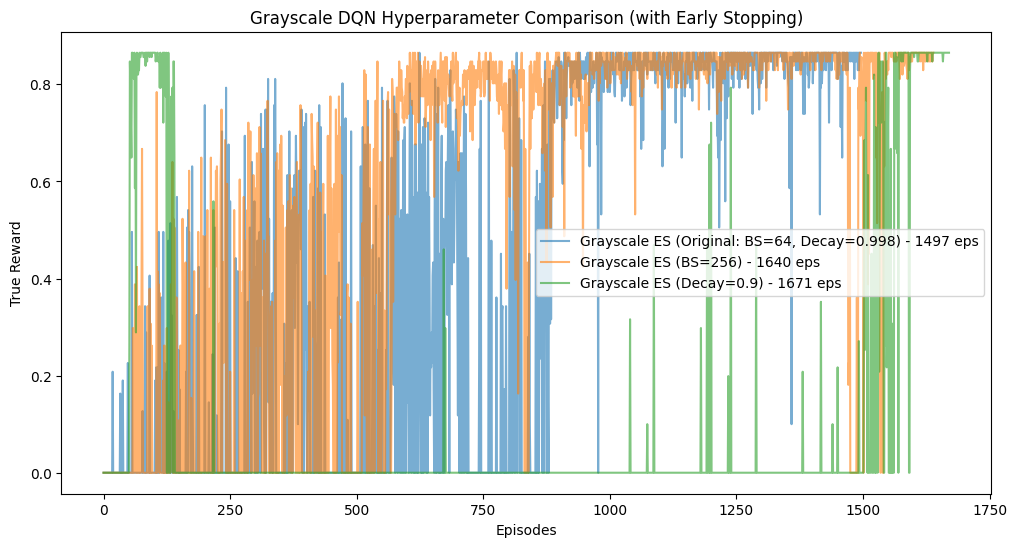

In [63]:
print("--- Hyperparameter Comparison Summary ---")
print(f"1. Grayscale ES (Original: BS=64, Decay=0.998): Converged in {len(rewards_grayscale_es)} episodes")
print(f"2. Grayscale ES (Batch Size = 256, Decay=0.998): Converged in {len(rewards_grayscale_es_bs256)} episodes")
print(f"3. Grayscale ES (Batch Size = 64, Decay=0.9): Converged in {len(rewards_grayscale_es_ed09)} episodes")

plt.figure(figsize=(12, 6))
plt.plot(rewards_grayscale_es, label=f"Grayscale ES (Original: BS=64, Decay=0.998) - {len(rewards_grayscale_es)} eps", alpha=0.6)
plt.plot(rewards_grayscale_es_bs256, label=f"Grayscale ES (BS=256) - {len(rewards_grayscale_es_bs256)} eps", alpha=0.6)
plt.plot(rewards_grayscale_es_ed09, label=f"Grayscale ES (Decay=0.9) - {len(rewards_grayscale_es_ed09)} eps", alpha=0.6)
plt.xlabel("Episodes")
plt.ylabel("True Reward")
plt.title("Grayscale DQN Hyperparameter Comparison (with Early Stopping)")
plt.legend()
plt.show()

### Compare and Test Early Stopping Models

Plots the rewards for the early stopping models, evaluates their performance, and saves/displays the gameplay videos.


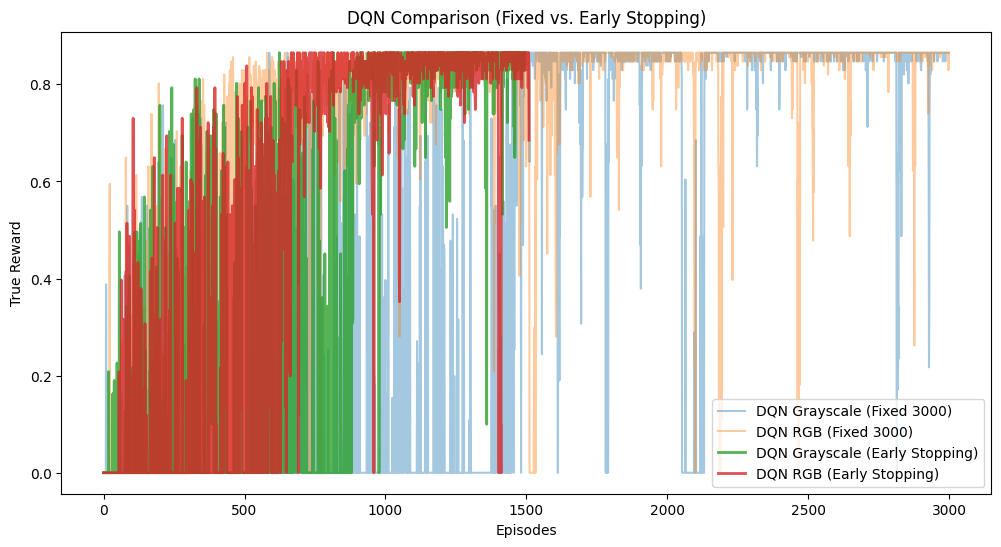

Model loaded from policy/DQN_Grayscale_ES_save.pth
--- Testing Grayscale ES Model ---
Finished in 15 steps
Video saved to video/dqn_grayscale_es_play.mp4


Model loaded from policy/DQN_RGB_ES_save.pth

--- Testing RGB ES Model ---
Finished in 100 steps
Video saved to video/dqn_rgb_es_play.mp4


In [64]:
# Plot Comparison including Early Stopping Models
plt.figure(figsize=(12, 6))
plt.plot(rewards_grayscale, label="DQN Grayscale (Fixed 3000)", alpha=0.4)
plt.plot(rewards_rgb, label="DQN RGB (Fixed 3000)", alpha=0.4)
plt.plot(rewards_grayscale_es, label="DQN Grayscale (Early Stopping)", alpha=0.8, linewidth=2)
plt.plot(rewards_rgb_es, label="DQN RGB (Early Stopping)", alpha=0.8, linewidth=2)
plt.xlabel("Episodes")
plt.ylabel("True Reward")
plt.title("DQN Comparison (Fixed vs. Early Stopping)")
plt.legend()
plt.show()

# Grayscale ES 모델 객체 생성 및 저장된 가중치 로드
model_grayscale_es = Model((1, 64, 64), 3).to(device)
model_grayscale_es = load_model(model_grayscale_es, "DQN_Grayscale_ES")

print("--- Testing Grayscale ES Model ---")
grayscale_es_frames = test_dqn(model_grayscale_es, use_grayscale=True)
display_video(grayscale_es_frames, "dqn_grayscale_es_play.mp4")

# RGB ES 모델 객체 생성 및 저장된 가중치 로드
model_rgb_es = Model((3, 64, 64), 3).to(device)
model_rgb_es = load_model(model_rgb_es, "DQN_RGB_ES")

print("\n--- Testing RGB ES Model ---")
rgb_es_frames = test_dqn(model_rgb_es, use_grayscale=False)
display_video(rgb_es_frames, "dqn_rgb_es_play.mp4")
